In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_31.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_24.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_9.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_17.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_10.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_8.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_15.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_14.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_30.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_26.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_16.1.2026.listens.csv
/kaggle/input/datasets/js042710/second3t1k/CLEARDATA/clean_1.2.2026.listens.csv
/kaggle/input/datasets/js042710

Load dữ liệu và định hình lại thời gian

In [2]:
#IMPORT THƯ VIỆN VÀ CẤU HÌNH
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Cấu hình đường dẫn
CONFIG = {
    'data_dir': '/kaggle/input/datasets/js042710/second3t1k/CLEARDATA'
}

print("Đã import thư viện và cấu hình thành công!")

Đã import thư viện và cấu hình thành công!


In [3]:
# ĐỌC VÀ GỘP DỮ LIỆU
print("MODULE 1: PHÂN CỤM NGƯỜI DÙNG")
print("\n 1. ĐANG ĐỌC VÀ GỘP DỮ LIỆU...")

# Lấy danh sách file
all_files = sorted(glob.glob(os.path.join(CONFIG['data_dir'], '*.csv')))
print(f"   Tìm thấy {len(all_files)} file CSV")

# Đọc từng file
df_list = []
cols_to_use = ['user_id', 'timestamp', 'recording_msid', 'artist_name']

for i, f in enumerate(all_files, 1):
    try:
        df_temp = pd.read_csv(f, usecols=cols_to_use)
        df_list.append(df_temp)
        if i % 5 == 0:  # In tiến độ mỗi 5 file
            print(f" Đã đọc {i}/{len(all_files)} files")
    except Exception as e:
        print(f"Lỗi đọc file {os.path.basename(f)}: {e}")

# Gộp dữ liệu
df_full = pd.concat(df_list, ignore_index=True)
del df_list  # Giải phóng bộ nhớ

# Xử lý timestamp
df_full['timestamp'] = pd.to_datetime(df_full['timestamp'])

# Hiển thị thông tin
print(f"\nTổng số dòng logs: {df_full.shape[0]:,}")
print(f" Số user duy nhất: {df_full['user_id'].nunique():,}")
print(f" Khoảng thời gian: {df_full['timestamp'].min()} đến {df_full['timestamp'].max()}")
print(f" Dung lượng dữ liệu: {df_full.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

MODULE 1: PHÂN CỤM NGƯỜI DÙNG

 1. ĐANG ĐỌC VÀ GỘP DỮ LIỆU...
   Tìm thấy 29 file CSV
 Đã đọc 5/29 files
 Đã đọc 10/29 files
 Đã đọc 15/29 files
 Đã đọc 20/29 files
 Đã đọc 25/29 files

Tổng số dòng logs: 80,631,061
 Số user duy nhất: 23,376
 Khoảng thời gian: 2005-02-13 23:59:59 đến 2026-02-05 00:03:33
 Dung lượng dữ liệu: 12.29 GB



 2. ĐANG TRÍCH XUẤT ĐẶC TRƯNG THỜI GIAN...
Giờ cao điểm nghe: 16h
Tỷ lệ nghe đêm: 19.4%
Tỷ lệ nghe cuối tuần: 26.0%


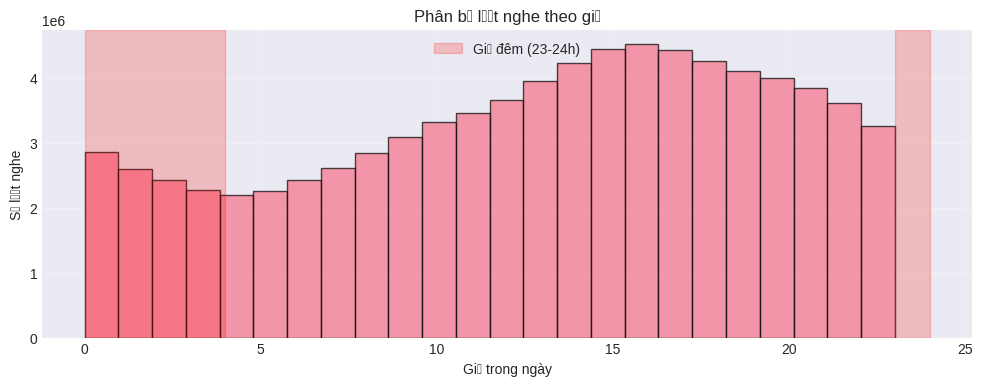

In [4]:
# FEATURE ENGINEERING - PHẦN 1 (ĐẶC TRƯNG THỜI GIAN)
print("\n 2. ĐANG TRÍCH XUẤT ĐẶC TRƯNG THỜI GIAN...")

# Trích xuất đặc trưng thời gian
df_full['hour'] = df_full['timestamp'].dt.hour
df_full['day_of_week'] = df_full['timestamp'].dt.dayofweek
df_full['is_weekend'] = df_full['day_of_week'].isin([5, 6]).astype(int)
df_full['is_night'] = df_full['hour'].apply(lambda x: 1 if (x >= 23 or x <= 4) else 0)

# Thống kê nhanh
print(f"Giờ cao điểm nghe: {df_full['hour'].mode()[0]}h")
print(f"Tỷ lệ nghe đêm: {df_full['is_night'].mean()*100:.1f}%")
print(f"Tỷ lệ nghe cuối tuần: {df_full['is_weekend'].mean()*100:.1f}%")

# Hiển thị phân bố giờ nghe
plt.figure(figsize=(12, 4))
plt.hist(df_full['hour'], bins=24, alpha=0.7, edgecolor='black')
plt.axvspan(23, 24, alpha=0.2, color='red', label='Giờ đêm (23-24h)')
plt.axvspan(0, 4, alpha=0.2, color='red')
plt.xlabel('Giờ trong ngày')
plt.ylabel('Số lượt nghe')
plt.title('Phân bố lượt nghe theo giờ')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# FEATURE ENGINEERING - PHẦN 2 (TỔNG HỢP THEO USER)
print("\n 3. ĐANG TỔNG HỢP DỮ LIỆU THEO USER...")

# Tổng hợp cơ bản
user_profile = df_full.groupby('user_id').agg(
    total_listens=('recording_msid', 'count'),
    unique_artists=('artist_name', 'nunique'),
    night_listens=('is_night', 'sum'),
    weekend_listens=('is_weekend', 'sum'),
    first_listen=('timestamp', 'min'),
    last_listen=('timestamp', 'max')
).reset_index()

print(f" Đã tạo profile cơ bản cho {len(user_profile)} users")

# Tính các tỷ lệ
user_profile['night_ratio'] = user_profile['night_listens'] / user_profile['total_listens']
user_profile['weekend_ratio'] = user_profile['weekend_listens'] / user_profile['total_listens']
user_profile['artist_diversity'] = user_profile['unique_artists'] / user_profile['total_listens']

# Tính số ngày hoạt động
user_profile['active_days'] = (user_profile['last_listen'] - user_profile['first_listen']).dt.days + 1
user_profile['avg_listens_per_day'] = user_profile['total_listens'] / user_profile['active_days']

print(f" Đã tính các chỉ số tỷ lệ và cường độ")


 3. ĐANG TỔNG HỢP DỮ LIỆU THEO USER...
 Đã tạo profile cơ bản cho 23376 users
 Đã tính các chỉ số tỷ lệ và cường độ
